In [55]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    precision_score,
    recall_score,
    fbeta_score,
    confusion_matrix,
    classification_report
)

In [56]:
df = pd.read_csv("../../../data/processed/feature_dataset.csv")

In [57]:
# One hot encoding for age and recording location
df = pd.get_dummies(df, columns=["Age"], drop_first=True)

df = pd.get_dummies(df, columns=["recording_location"], drop_first=True)

df = pd.get_dummies(df, columns=["Murmur"], drop_first=True)

df["Sex"] = df["Sex"].map({
    "Female": 0,
    "Male": 1
})

df["Outcome"] = df["Outcome"].map({
    "Normal": 0,
    "Abnormal": 1
})

print(df.columns.tolist())

['Patient ID', 'Outcome', 'split', 'Sex', 'Height', 'Weight', 'Pregnancy status', 'file', 'Campaign', 'Additional ID', 'rms', 'peak', 'variance', 'mean', 'std', 'skew', 'kurtosis', 'zcr', 'dynamic_range', 'spectral_centroid', 'spectral_bandwidth', 'spectral_rolloff', 'spectral_flatness', 'band_energy_20_50', 'band_energy_50_100', 'band_energy_100_200', 'band_energy_200_400', 'band_energy_400_800', 'mfcc_1_mean', 'mfcc_1_std', 'mfcc_d1_1_mean', 'mfcc_d1_1_std', 'mfcc_d2_1_mean', 'mfcc_d2_1_std', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_d1_2_mean', 'mfcc_d1_2_std', 'mfcc_d2_2_mean', 'mfcc_d2_2_std', 'mfcc_3_mean', 'mfcc_3_std', 'mfcc_d1_3_mean', 'mfcc_d1_3_std', 'mfcc_d2_3_mean', 'mfcc_d2_3_std', 'mfcc_4_mean', 'mfcc_4_std', 'mfcc_d1_4_mean', 'mfcc_d1_4_std', 'mfcc_d2_4_mean', 'mfcc_d2_4_std', 'mfcc_5_mean', 'mfcc_5_std', 'mfcc_d1_5_mean', 'mfcc_d1_5_std', 'mfcc_d2_5_mean', 'mfcc_d2_5_std', 'mfcc_6_mean', 'mfcc_6_std', 'mfcc_d1_6_mean', 'mfcc_d1_6_std', 'mfcc_d2_6_mean', 'mfcc_d2_6_std', 'mfcc

In [58]:
# -----------------------------
# Split using your predefined split
# -----------------------------
train_df = df[df["split"] == "train"]
val_df   = df[df["split"] == "val"]
test_df  = df[df["split"] == "test"]

In [59]:
# -----------------------------
# Prepare features
# -----------------------------
drop_cols = ["Patient ID", "Outcome", "split", "file", "Campaign", "Additional ID", "Height", "Weight"]

drop_cols = drop_cols + ["rms"]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df["Outcome"]

X_val = val_df.drop(columns=drop_cols)
y_val = val_df["Outcome"]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df["Outcome"]

In [60]:
print(X_train.shape, y_train.shape)

(2220, 107) (2220,)


In [61]:
# import numpy as np
# import pandas as pd
# from statsmodels.stats.outliers_influence import variance_inflation_factor

# # Keep only numeric columns
# X_vif = train_df.select_dtypes(include=[np.number]).copy()

# # Remove target columns if they are numeric
# cols_to_remove = [
#     "outcome",      # adjust to your target column name
#     "murmur",       # adjust if present
# ]

# X_vif = X_vif.drop(
#     columns=[c for c in cols_to_remove if c in X_vif.columns],
#     errors="ignore"
# )

# # Remove columns with zero variance
# X_vif = X_vif.loc[:, X_vif.nunique() > 1]

# # Remove inf/nan rows
# X_vif = X_vif.replace([np.inf, -np.inf], np.nan)
# X_vif = X_vif.dropna()

# vif = pd.DataFrame({
#     "feature": X_vif.columns,
#     "VIF": [
#         variance_inflation_factor(X_vif.values, i)
#         for i in range(X_vif.shape[1])
#     ]
# })

# vif = vif.sort_values("VIF", ascending=False)

# print(vif)

In [62]:
# -----------------------------
# Scaling (IMPORTANT for linear models)
# -----------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [63]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(
    np.array(y_train),
    dtype=torch.float32
).reshape(-1, 1)

y_val_tensor = torch.tensor(
    np.array(y_val),
    dtype=torch.float32
).reshape(-1, 1)

y_test_tensor = torch.tensor(
    np.array(y_test),
    dtype=torch.float32
).reshape(-1, 1)

In [64]:
import torch.nn as nn

# class MLP(nn.Module):
#     def __init__(self, n_features):
#         super().__init__()

#         self.net = nn.Sequential(
#             nn.Linear(n_features, 128),
#             nn.ReLU(),
#             nn.Dropout(0.3),

#             nn.Linear(128, 64),
#             nn.ReLU(),

#             nn.Linear(64, 1)
#         )

#     def forward(self, x):
#         return self.net(x)

class MLP(nn.Module):
    def __init__(self, n_features):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(n_features, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

In [65]:
n_features = X_train.shape[1]

model = MLP(n_features)

In [66]:
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

In [67]:
n_epochs = 300

best_val_loss = float("inf")
best_state = None

for epoch in range(n_epochs):

    model.train()

    optimizer.zero_grad()

    logits = model(X_train_tensor)

    loss = criterion(
        logits,
        y_train_tensor
    )

    loss.backward()

    optimizer.step()

    model.eval()

    with torch.no_grad():

        val_logits = model(X_val_tensor)

        val_loss = criterion(
            val_logits,
            y_val_tensor
        )

    if val_loss < best_val_loss:

        best_val_loss = val_loss.item()

        best_state = {
            k: v.cpu().clone()
            for k, v in model.state_dict().items()
        }

    if epoch % 10 == 0:

        print(
            f"Epoch {epoch:3d} | "
            f"Train Loss {loss.item():.4f} | "
            f"Val Loss {val_loss.item():.4f}"
        )

Epoch   0 | Train Loss 0.7172 | Val Loss 0.6890
Epoch  10 | Train Loss 0.6365 | Val Loss 0.6372
Epoch  20 | Train Loss 0.5967 | Val Loss 0.5951
Epoch  30 | Train Loss 0.5554 | Val Loss 0.5776
Epoch  40 | Train Loss 0.5263 | Val Loss 0.5769
Epoch  50 | Train Loss 0.4859 | Val Loss 0.5805
Epoch  60 | Train Loss 0.4470 | Val Loss 0.5996
Epoch  70 | Train Loss 0.4189 | Val Loss 0.6186
Epoch  80 | Train Loss 0.3952 | Val Loss 0.6399
Epoch  90 | Train Loss 0.3610 | Val Loss 0.6599
Epoch 100 | Train Loss 0.3438 | Val Loss 0.6936
Epoch 110 | Train Loss 0.3101 | Val Loss 0.7147
Epoch 120 | Train Loss 0.2967 | Val Loss 0.7471
Epoch 130 | Train Loss 0.2763 | Val Loss 0.7651
Epoch 140 | Train Loss 0.2598 | Val Loss 0.7809
Epoch 150 | Train Loss 0.2352 | Val Loss 0.8172
Epoch 160 | Train Loss 0.2249 | Val Loss 0.8399
Epoch 170 | Train Loss 0.2143 | Val Loss 0.8702
Epoch 180 | Train Loss 0.1949 | Val Loss 0.8653
Epoch 190 | Train Loss 0.1812 | Val Loss 0.8765
Epoch 200 | Train Loss 0.1673 | Val Loss

In [68]:
model.load_state_dict(best_state)

<All keys matched successfully>

In [69]:
model.eval()

with torch.no_grad():

    val_probs = torch.sigmoid(
        model(X_val_tensor)
    ).numpy().flatten()

best_threshold = 0.5
best_f2 = -1

for threshold in np.arange(0.01, 1.0, 0.01):

    preds = (val_probs >= threshold).astype(int)

    precision = precision_score(
        y_val,
        preds,
        zero_division=0
    )

    if precision < 0.5:
        continue

    f2 = fbeta_score(
        y_val,
        preds,
        beta=2,
        zero_division=0
    )

    if f2 > best_f2:

        best_f2 = f2
        best_threshold = threshold

print()
print("Best Validation Threshold:", best_threshold)
print("Best Validation F2:", best_f2)


Best Validation Threshold: 0.24000000000000002
Best Validation F2: 0.8172706245181187


In [70]:
# Generate probabilities
with torch.no_grad():

    test_probs = torch.sigmoid(
        model(X_test_tensor)
    ).numpy().flatten()


# Apply threshold
test_preds = (
    test_probs >= best_threshold
).astype(int)

# Compute metrics
precision = precision_score(
    y_test,
    test_preds
)

recall = recall_score(
    y_test,
    test_preds
)

f2 = fbeta_score(
    y_test,
    test_preds,
    beta=2
)

print()
print("===== TEST RESULTS =====")
print(f"Threshold : {best_threshold:.2f}")
print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"F2 Score  : {f2:.3f}")
    


===== TEST RESULTS =====
Threshold : 0.24
Precision : 0.522
Recall    : 0.966
F2 Score  : 0.826


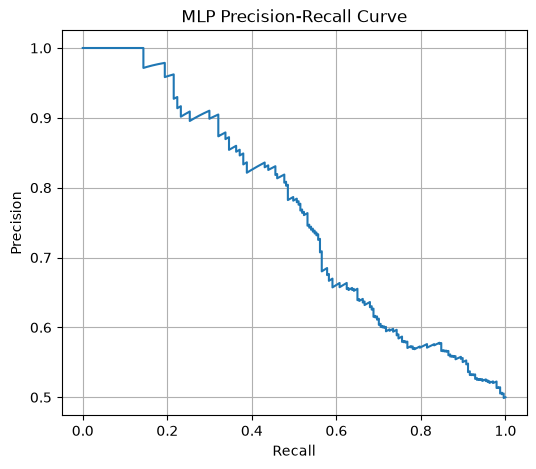

In [71]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision_curve, recall_curve, _ = (
    precision_recall_curve(
        y_test,
        test_probs
    )
)

plt.figure(figsize=(6, 5))
plt.plot(recall_curve, precision_curve)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("MLP Precision-Recall Curve")
plt.grid(True)

plt.show()

In [72]:
cm = confusion_matrix(
    y_test,
    test_preds
)

print()
print(cm)


[[ 27 210]
 [  8 229]]
